# Phase 3 — GDELT Sentiment + 3rd Eye Oversight Agent

Thin notebook calling `scaata` package functions.

**Known limitation**: live GDELT access was rate-limited/blocked from this dev sandbox's IP regardless of backoff (verified: query-building and the causal trading-day alignment logic both work correctly, and are unit-tested in `tests/test_gdelt_alignment.py` — only the live network call couldn't be exercised here). This notebook defaults to `USE_MOCK_DATA = True` (synthetic sentiment) so it's still fully runnable end-to-end; set it to `False` to attempt a live GDELT pull (respect the API's requested 1-request-per-5-seconds rate limit — already built into `scaata.data.gdelt`).

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from scaata.config import FEATURE_COLUMNS
from scaata.data.loaders import load_market_data
from scaata.data.gdelt import fetch_daily_tone_timeline, align_sentiment_to_trading_days, mock_daily_sentiment
from scaata.features.technical import add_features
from scaata.features.sentiment import mock_headlines_by_date, attach_finbert_daily_score, combine_sentiment_signals
from scaata.regimes.detector import threshold_regime_labels
from scaata.thirdeye.correlator import era_correlation_report, granger_causality_test
from scaata.thirdeye.narrative import generate_narrative, faithfulness_check
from scaata.thirdeye.plots import plot_sentiment_overlaid_price, plot_event_study, plot_rolling_sentiment_volatility_correlation

USE_MOCK_DATA = True
TICKER = 'AAPL'
START, END = '2020-01-01', '2024-01-01'

print(f"USE_MOCK_DATA={USE_MOCK_DATA}")

USE_MOCK_DATA=True


## 1. Market data + causal regime labels (reusing Phase 1)

In [2]:
raw_df = load_market_data([TICKER], START, END, use_cache=True)
featured_df = add_features(raw_df)
labeled_df = threshold_regime_labels(featured_df)

market_df = labeled_df.set_index(labeled_df.index)[['Close', 'returns', 'rolling_vol', 'regime']]
print(market_df.shape)

(957, 4)


## 2. Sentiment: GDELT tone + FinBERT, aligned to trading days

In [3]:
if USE_MOCK_DATA:
    sentiment_raw = mock_daily_sentiment(TICKER, market_df.index, seed=0)
else:
    sentiment_raw = fetch_daily_tone_timeline(TICKER, START, END)
    sentiment_raw = align_sentiment_to_trading_days(sentiment_raw)

headline_sample_dates = market_df.index[::15]  # sparse sample to keep FinBERT inference cost bounded
headlines = mock_headlines_by_date(headline_sample_dates, seed=0)
sentiment_scored = attach_finbert_daily_score(sentiment_raw, headlines)
sentiment_df = combine_sentiment_signals(sentiment_scored)

print(sentiment_df.head())
print(f"\nGDELT tone vs FinBERT correlation (data-quality cross-check): "
      f"{sentiment_df['tone'].corr(sentiment_df['finbert_score']):.3f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

        date ticker      tone  mention_volume  finbert_score  sentiment_score
0 2020-03-13   AAPL  0.251460              28      -0.939467        -0.457160
1 2020-03-16   AAPL -0.264210              45            NaN        -0.026421
2 2020-03-17   AAPL  1.280845               8            NaN         0.128085
3 2020-03-18   AAPL  0.209800              41            NaN         0.020980
4 2020-03-19   AAPL -1.071339              21            NaN        -0.107134

GDELT tone vs FinBERT correlation (data-quality cross-check): 0.073


## 3. Graphs

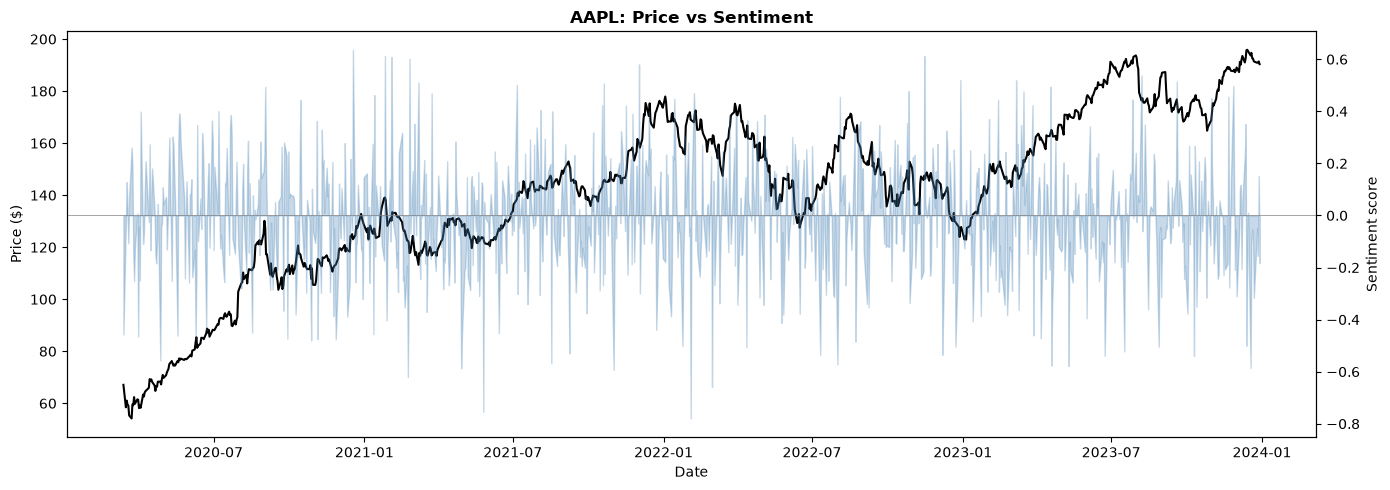

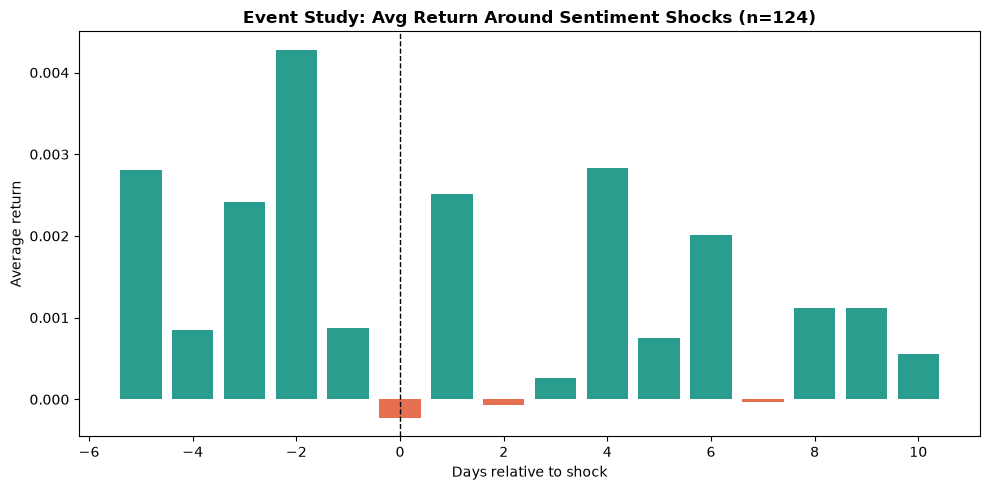

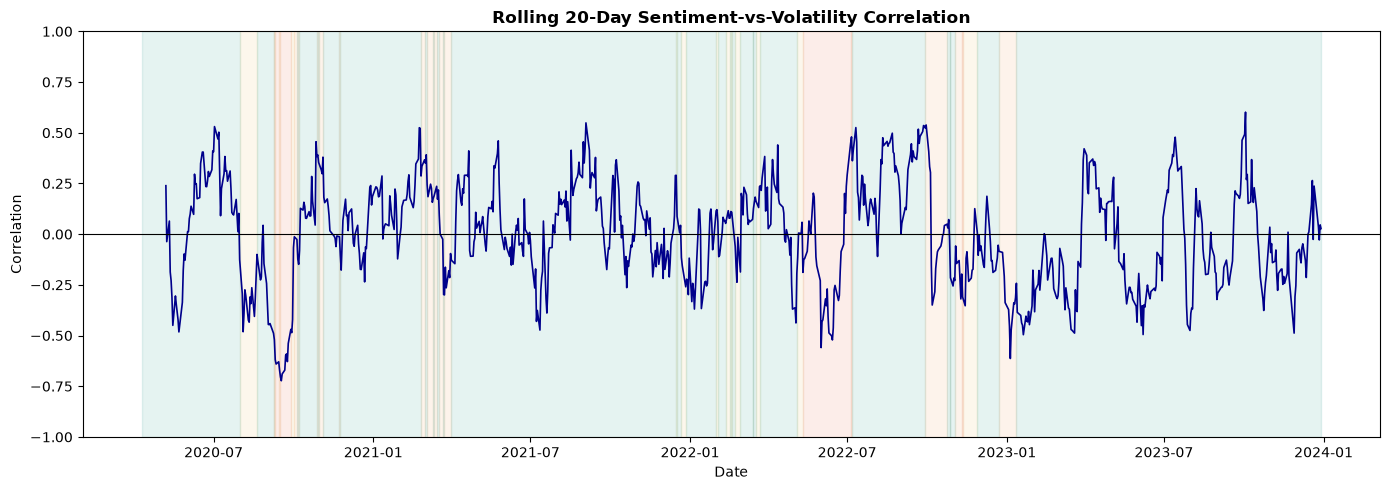

In [4]:
sentiment_indexed = sentiment_df.set_index('date')['sentiment_score']

plot_sentiment_overlaid_price(market_df['Close'], sentiment_indexed, f'{TICKER}: Price vs Sentiment')
plt.tight_layout()
plt.show()

plot_event_study(market_df['returns'], sentiment_indexed)
plt.tight_layout()
plt.show()

plot_rolling_sentiment_volatility_correlation(sentiment_indexed, market_df['rolling_vol'], regime_labels=market_df['regime'])
plt.tight_layout()
plt.show()

## 4. 3rd Eye: 2020-era vs 2026-era comparison + Granger causality + narrative

In [5]:
mid = market_df.index[len(market_df) // 2]
era_early = (str(market_df.index[0].date()), str(mid.date()))
era_late = (str(mid.date()), str(market_df.index[-1].date()))

report = era_correlation_report(market_df, sentiment_df, era_early, era_late)
print('era_early:', report['era_early'])
print('era_late:', report['era_late'])

granger = granger_causality_test(sentiment_indexed, market_df['rolling_vol'], max_lag=5)
print('\ngranger:', granger)

narrative = generate_narrative(report, granger)
print('\n--- 3rd Eye Narrative ---')
print(narrative)

check = faithfulness_check(narrative, report)
print('\n--- Faithfulness Check ---')
print(check)

era_early: {'n_days': 479, 'corr_vol': 0.006979747790594547, 'corr_next_day_return': 0.06697273759823268, 'mean_coverage_volume': 25.091858037578287}
era_late: {'n_days': 479, 'corr_vol': 0.04783040913391084, 'corr_next_day_return': -0.07277780163128424, 'mean_coverage_volume': 25.144050104384135}

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.4605  , p=0.0197  , df_denom=934, df_num=1
ssr based chi2 test:   chi2=5.4781  , p=0.0193  , df=1
likelihood ratio test: chi2=5.4621  , p=0.0194  , df=1
parameter F test:         F=5.4605  , p=0.0197  , df_denom=934, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.7881  , p=0.0621  , df_denom=931, df_num=2
ssr based chi2 test:   chi2=5.6062  , p=0.0606  , df=2
likelihood ratio test: chi2=5.5895  , p=0.0611  , df=2
parameter F test:         F=2.7881  , p=0.0621  , df_denom=931, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.1723  , p=0.0898  , d

## Done criteria for this phase
- No next-day leakage in sentiment alignment (verified by `tests/test_gdelt_alignment.py`).
- GDELT-native tone and FinBERT scores are at least weakly correlated (checked above; if wildly uncorrelated, investigate entity-matching precision before trusting either).
- The narrative's directional claim matches the report's actual sign comparison (verified above by `faithfulness_check`, and by `tests/test_thirdeye.py`).
- Set `USE_MOCK_DATA = False` and retry (respecting GDELT's rate limit) once network access to GDELT is available for the real research run — the mock path exists only so this notebook is runnable everywhere.